# Predstavitev podatkov 200 najboljših evropskih univerz
### Uvod
V tej datoteki bodo predstavljeni in analizirani podatki o 200 najboljših evropskih univerzah. Analiza bo zajemala podatke o evropskem, svetovnem in državnem rangu univerze, velikost, selektivnost, ter zgornjo mejo cene šolanja za lokalne študente dodiplomskega študija.

### Uvoz potrebnih knjižnjic

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

### Uvoz csv datoteke s podatki
Spodnja tabela okvirno prikazuje v kakšni obliki so podatki.

In [197]:
podatki_univerz = pd.read_csv("universities/universities.csv", index_col = 'Evropski rank')
podatki_univerz

,Univerza,Mesto,Država,Svetovni rank,Državni rank,URL podstrani,Velikost,Selektivnost,Leto ustanovitve,Cena šolanja,Zgornja meja cene
Evropski rank,,,,,,,,,,,
1,University of Oxford,Oxford,United Kingdom,9,1,https://www.unirank.org/gb/uni/university-of-o...,large-sized,very selective,1096,"12,500-14,999 US$ (11,390-13,670 Euro)","14,999 US$"
2,University of Cambridge,Cambridge,United Kingdom,16,2,https://www.unirank.org/gb/uni/university-of-c...,large-sized,extremely selective,1209,"12,500-14,999 US$ (11,390-13,670 Euro)","14,999 US$"
3,University College London,London,United Kingdom,41,3,https://www.unirank.org/gb/uni/university-coll...,very large-sized,not reported,1826,"10,000-12,499 US$ (9,110-11,390 Euro)","12,499 US$"
4,Eidgenössische Technische Hochschule Zürich,Zürich,Switzerland,45,1,https://www.unirank.org/ch/uni/eidgenossische-...,large-sized,not reported,1855,"1,000-2,499 US$ (910-2,280 Euro)","2,499 US$"
5,University of Edinburgh,Edinburgh,United Kingdom,50,4,https://www.unirank.org/gb/uni/university-of-e...,very large-sized,not reported,1583,"1,000-2,499 US$ (910-2,280 Euro)","2,499 US$"
...,...,...,...,...,...,...,...,...,...,...,...
196,Universität Konstanz,Konstanz,Germany,476,44,https://www.unirank.org/de/uni/universitat-kon...,small-sized,not reported,1966,0-999 US$ (0-910 Euro),999 US$
197,Institut d'Études Politiques de Paris,Paris,France,477,14,https://www.unirank.org/fr/uni/institut-d-etud...,medium-sized,extremely selective,1872,"10,000-12,499 US$ (9,110-11,390 Euro)","12,499 US$"
198,Universität des Saarlandes,Saarbrücken,Germany,482,45,https://www.unirank.org/de/uni/universitat-des...,large-sized,very selective,1948,0-999 US$ (0-910 Euro),999 US$


## Zastopanost evropskih držav
Za začetek si bomo ogledali kakšen delež zasegajo evropske države s svojimi univerzami v lestvici top 200. Moja hipoteza je, da bodo največji delež zasegale Nemčija, Združeno kraljestvo in Francija.

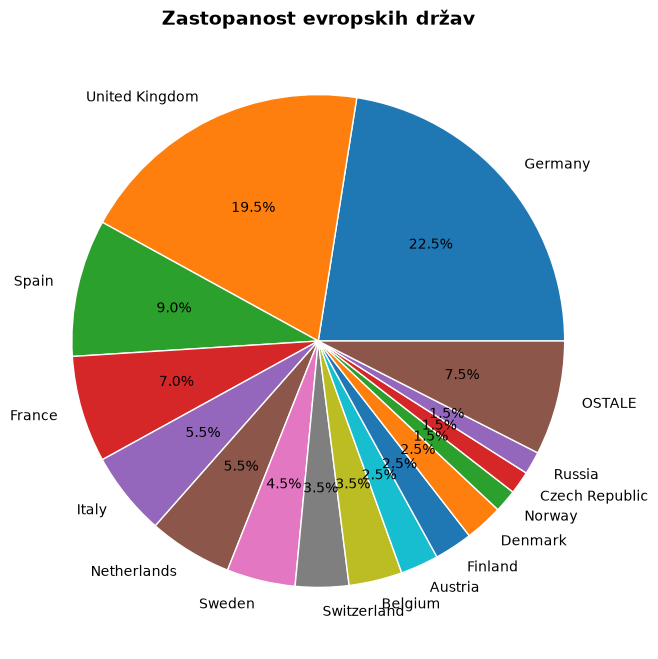

In [206]:
delež = podatki_univerz['Država'].value_counts()
prvih_15 = delež.head(15)
ostale = delež[15:].sum() 

podatki_za_graf = prvih_15.copy()
podatki_za_graf['OSTALE'] = ostale

plt.figure (figsize=(10,8))
plt.pie(
    podatki_za_graf,
    labels=podatki_za_graf.index,
    autopct='%1.1f%%',
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )
plt.title('Zastopanost evropskih držav', fontsize=14, fontweight='bold')
plt.show()

Moja hipoteza je deloma pravilna: Nemčija in Združeno kraljestvo zasegata prvi dve mesti, francoske univerze pa se po deležu med top 200 pojavijo na četrtem mestu za Španijo. 

### Uspešnost držav
Naslednja stvar, ki jo je pri analizi treba upoštevati, je, katere države so dejansko najuspešnejše na evropski lestvici top 200 univerz. Natančneje, v katerih državah je prvih 10 najuspešnejših univerz in kakšni so njihovi deleži univerz v top 10. Če preletimo začetek razpredelnice podatkov, lahko predvidevamo, da ima v top 10 največ univerz Združeno kraljestvo.

In [199]:
top_10 = podatki_univerz.head(10)
zastopanost_top10 = top_10['Država'].value_counts()
zastopanost_top10
zastopanost_top200 = podatki_univerz.head(200)['Država'].value_counts()

primerjava = pd.DataFrame({'Top 10': zastopanost_top10, 'Top 200': zastopanost_top200.loc[zastopanost_top10.index]}) 
primerjava

top_10 = podatki_univerz.head(10)
zastopanost_top10 = top_10['Država'].value_counts()
zastopanost_top10
zastopanost_top200 = podatki_univerz.head(200)['Država'].value_counts()

primerjava = pd.DataFrame({'Top 10': zastopanost_top10, 'Top 200': zastopanost_top200.loc[zastopanost_top10.index]}) 

primerjava['Delež top 10 med top 200'] = (primerjava['Top 10'] / primerjava['Top 200']) * 100
primerjava['Delež top 10 med top 200'] = primerjava['Delež top 10 med top 200'].round(2).astype(str) + '%'
primerjava 



,Top 10,Top 200,Delež top 10 med top 200
Država,,,
United Kingdom,5,39,12.82%
Switzerland,1,7,14.29%
Germany,1,45,2.22%
Austria,1,5,20.0%
Belgium,1,7,14.29%
Italy,1,11,9.09%


Analiza je pokazala, da ima Združeno kraljestvo največ univerz med desetimi najboljšimi evropskimi univerzami. Če pa število univerz v top 10 primerjamo s številom univerz v top 200, ima najvišji delež Avstrija. Od svojih petih univerz v top 200 ima namreč eno v top 10, kar predstavlja največji delež med vsemi zastopanimi državami.

### Ali cena dodiplomskega študija vpliva na uvrstitev univerze v lestvico najboljših univerz?
Opozorilo: Če se izpiše napaka pri spodnjem grafu, prosim da zaženete spodnjo kodo za branje csv datoteke.

In [203]:
podatki_univerz = pd.read_csv("universities/universities.csv", index_col = 'Evropski rank')

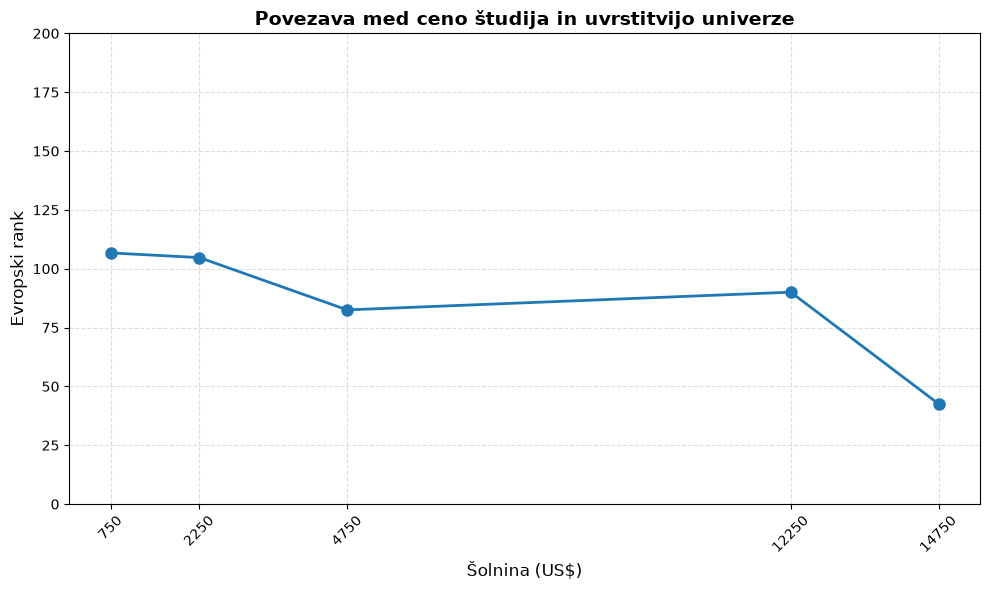

In [201]:
#če koda ne deluje, prosim da še enkrat zaženite zgornjo kodo za branje csv datoteke.
podatki_univerz = podatki_univerz.reset_index()

podatki_univerz['Zgornja meja cene'] = pd.to_numeric(
    podatki_univerz['Zgornja meja cene'].str.replace(' ', '').str.replace('US$', '').str.replace(',', ''),
    errors='coerce'
    )


podatki_univerz['skupine_cen'] = (podatki_univerz['Zgornja meja cene'] // 250) * 250
intervali = (
    podatki_univerz.groupby('skupine_cen')['Evropski rank'].mean()
    .sort_index()
)


plt.figure(figsize=(10, 6))
plt.title('Povezava med ceno študija in uvrstitvijo univerze', fontsize=14, fontweight='bold')
plt.xlabel('Šolnina (US$)', fontsize=12)
plt.ylabel('Evropski rank', fontsize=12)
plt.plot(intervali.index, intervali.values, marker="o", linewidth=2, markersize=8)
plt.xticks(intervali.index, rotation=45)
plt.ylim(0, 200)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Graf nam okvirno prikazuje, da imajo univerze, ki so se uvrščajo na prvih nekaj mest, višje šolnine. To kaže na povezanost med stopnjo šolnine in uvrstitvijo univerze na evropski lestvici. Treba pa je upoštevati, da na spletni strani za nekatere univerzah šolnine niso evidentirane, zato ta analiza za graf ne upošteva vseh 200 univerz.

In [202]:
stevilo_not_reported = (podatki_univerz['Zgornja meja cene'].isna()).sum()
print (f"Število univerz, ki niso poročale o ceni študija: {stevilo_not_reported}")

Število univerz, ki niso poročale o ceni študija: 6


### Ali leto ustanovitve vpliva na uvrstitev univerze na evropski lestvici top 200.
Moja hipoteza je, da bodo starejše univerze visoko na evropski lestvici.

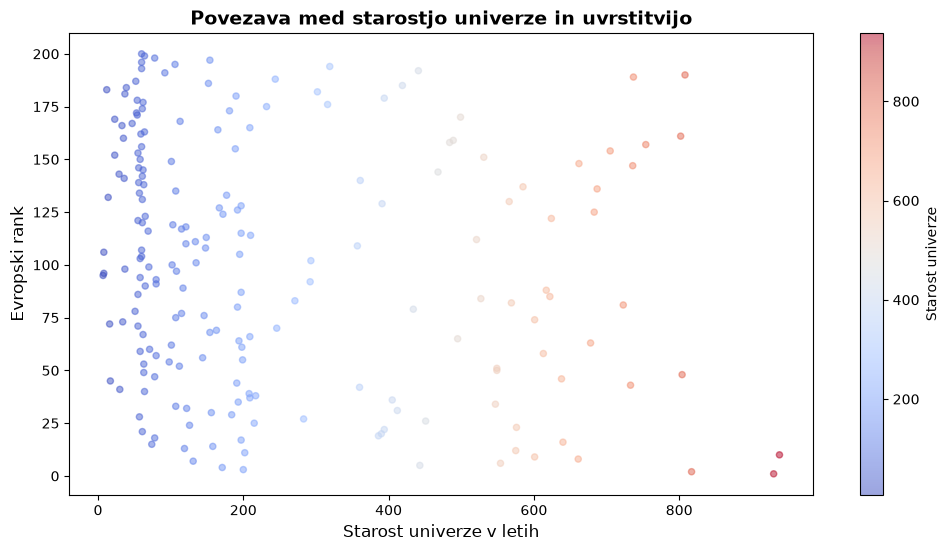

In [113]:
trenutno_leto = date.today().year

podatki_univerz['Leto ustanovitve'] = pd.to_numeric(podatki_univerz['Leto ustanovitve'], errors='coerce')
podatki_univerz['Starost univerze'] = trenutno_leto - podatki_univerz['Leto ustanovitve']

plt.figure(figsize=(12, 6))
scatter = plt.scatter(podatki_univerz['Starost univerze'], podatki_univerz['Evropski rank'], s=20, c=podatki_univerz['Starost univerze'], cmap="coolwarm",alpha=0.5)
plt.title('Povezava med starostjo univerze in uvrstitvijo', fontsize=14, fontweight='bold')
plt.xlabel('Starost univerze v letih', fontsize=12)
plt.ylabel('Evropski rank', fontsize=12)
plt.colorbar(scatter, label='Starost univerze')
plt.show()

Iz grafa okvirno ne moremo potrditi hipoteze, da so starejše univerze višje na evropski top 200 lestvici, čeprav sta nastarejši dve univerzi v top 25. Razpršenost grafa nakazuje na nepoveznost med starostjo univerz in evropskim rangom.

### Stopnje selektivnosti univerz
Pri pregledu stopenj selektivnosti bomo upoštevali, da na spletni strani podatki o selektivnosti niso objavljeni za vse univerze.

In [204]:
stevilo_not_reported = (podatki_univerz['Selektivnost'] == 'not reported').sum()
stevilo_not_available = (podatki_univerz['Selektivnost'] == 'not available').sum()
brez_podatka = stevilo_not_reported + stevilo_not_available
print(f"Število univerz brez podatka o selektivnosti: {brez_podatka}")
print (f"Število univerz s podatkom o selektivnosti: {200 - brez_podatka}")

Število univerz brez podatka o selektivnosti: 158
Število univerz s podatkom o selektivnosti: 42


Za 42 univerz, za katere so na spletni strani podatki o selektivnosti na voljo, si oglejmo razmerje med posameznimi stopnjami selektivnosti. 

In [ ]:
podatki_s_selektivnostjo = podatki_univerz[~podatki_univerz['Selektivnost'].isin(['not reported', 'not available'])]
stopnje_selektivnosti= podatki_s_selektivnostjo['Selektivnost'].value_counts()
stopnje_selektivnosti

Selektivnost
very selective          14
extremely selective      9
moderately selective     9
averagely selective      8
least selective          2
Name: count, dtype: int64

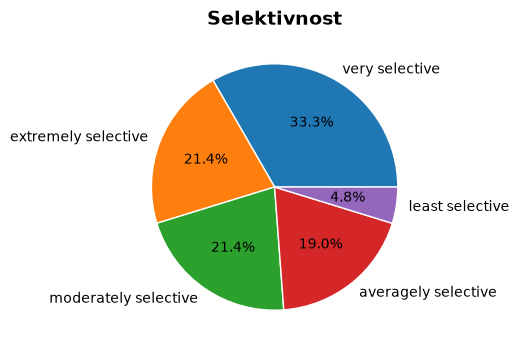

In [205]:
delež = podatki_univerz[~podatki_univerz['Selektivnost'].isin(['not reported', 'not available'])]['Selektivnost'].value_counts()
plt.figure (figsize=(4,4))
plt.pie(
        delež,
        labels=delež.index,
        autopct='%1.1f%%',
        textprops={"fontsize": 10},
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
        )
plt.title('Selektivnost', fontsize=14, fontweight='bold')
plt.show()

Tortni graf prikazuje, da je največ univerz (33.3 %) označenih kot zelo selektivnih, najmanj pa jih je označenih kot malo selektivnih (4.8 %)

### Vpliv velikosti na selektivnost
Pri obravnavi vpliva velikosti univerze na selektivnost je treba upoštevati, da pri analizi ne bomo upoštevali univerz, ki nimajo podatkov o selektivnosti. Moja hipoteza je, da imajo manjše univerze višjo stopnjo selektivnosti kot pa večje.

In [140]:
print(podatki_univerz['Velikost'].value_counts())


Velikost
large-sized         115
very large-sized     71
medium-sized         11
small-sized           3
Name: count, dtype: int64


In [ ]:
print(podatki_s_selektivnostjo['Velikost'].value_counts())

Velikost
large-sized         27
very large-sized    13
medium-sized         2
Name: count, dtype: int64


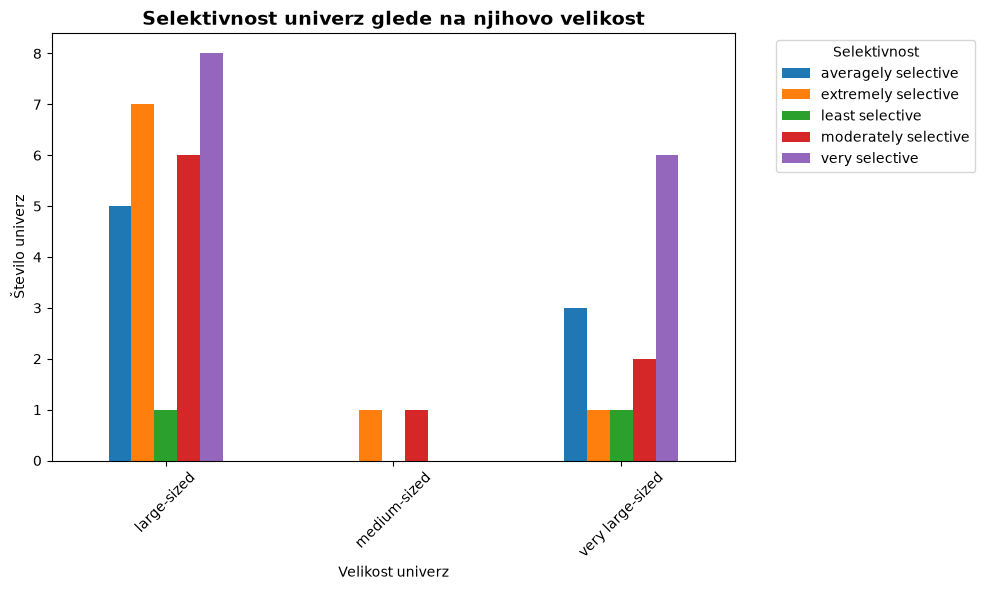

In [167]:

crosstab_odstotki = pd.crosstab(
    podatki_s_selektivnostjo['Velikost'],
    podatki_s_selektivnostjo['Selektivnost']
    )

crosstab_odstotki.plot(kind='bar', figsize=(10,6))
plt.title('Selektivnost univerz glede na njihovo velikost', fontsize=14, fontweight='bold')
plt.ylabel('Število univerz')
plt.xlabel('Velikost univerz')
plt.xticks(rotation=45)
plt.legend(title='Selektivnost', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

Graf ne potrjuje naše hipoteze: zelo velike univerze in velike univerze so največkrat označene kot zelo selektivne in celo ekstremno selektivne.

### Vpliv selektivnosti na evropsko lestvico najboljših 200 univerz
Moja predvidevanja so, da se bodo univerze z visoko stopnjo selektivnosti razvrstile višje na evropski lestvici top 200 univerz.

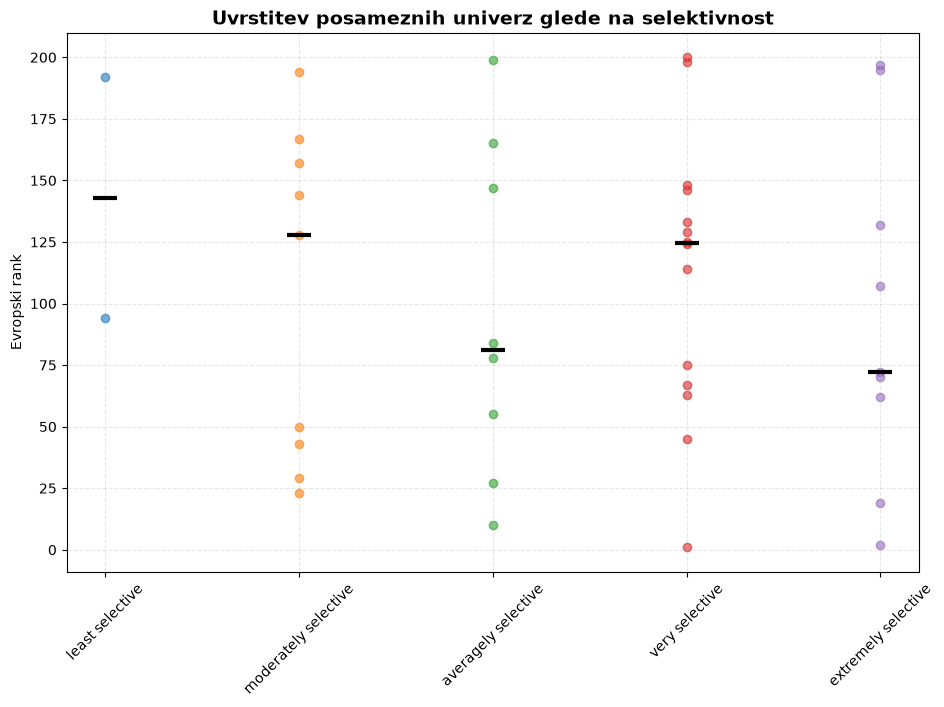

In [185]:
podatki_s_selektivnostjo = podatki_univerz[~podatki_univerz['Selektivnost'].isin(['not reported', 'not available'])]
vrstni_red = ['least selective', 'moderately selective', 'averagely selective', 'very selective', 'extremely selective']
plt.figure(figsize=(11,7))

stopnje_selektivnosti = podatki_s_selektivnostjo['Selektivnost'].unique()
for i, stopnja in enumerate(vrstni_red):
    subset = podatki_s_selektivnostjo[podatki_s_selektivnostjo['Selektivnost'] == stopnja]
    mediana = subset['Evropski rank'].median()
    plt.scatter([i] * len(subset), subset['Evropski rank'], alpha=0.6)
    plt.scatter(i, mediana, color='black', marker='_', s=300, linewidths=3, zorder=5)

plt.xticks(range(len(vrstni_red)), vrstni_red, rotation=45)
plt.ylabel('Evropski rank')
plt.title('Uvrstitev posameznih univerz glede na selektivnost', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout
plt.show()

Graf razpršenosti, kjer črne črtice prikazujejo mediano, deloma potrdijo mojo hipotezo. Trend je razviden, kljub precejšnji razpršenosti posameznih univerz: z naraščujočo stopnjo selektivnosti se mediana evropskega ranga univerz izboljšuje (znižuje). 

### Povezava med evropskim in svetovnim rangom univerz
Predvidevam, da bo graf pokazal linearno naraščujočo povezavo med evropskim in svetovnim rangom univerz.

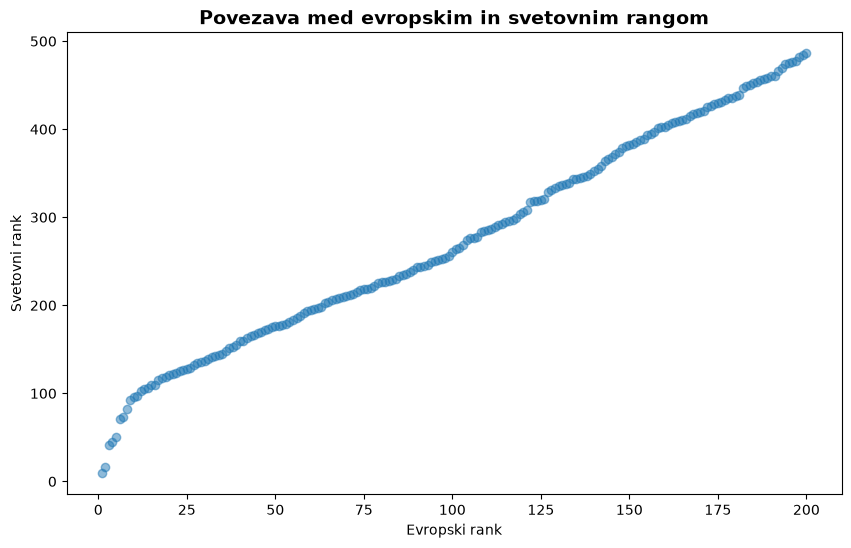

In [225]:
plt.figure(figsize=(10,6))
plt.scatter(podatki_univerz['Evropski rank'], podatki_univerz['Svetovni rank'], alpha=0.5)
plt.xlabel('Evropski rank')
plt.ylabel('Svetovni rank')
plt.title('Povezava med evropskim in svetovnim rangom', fontsize=14, fontweight='bold')
plt.tight_layout
plt.show()

Graf jasno potrdi moje predvidevanje, saj je opazen jasen trend linearne pozitivne povezave med svetovnim rangom in evropskim rangom.

### Povezava med evropskim in državnim rangom
Predvidevam, da bo državni rang univerz naraščal skupaj z evropskim rangom.

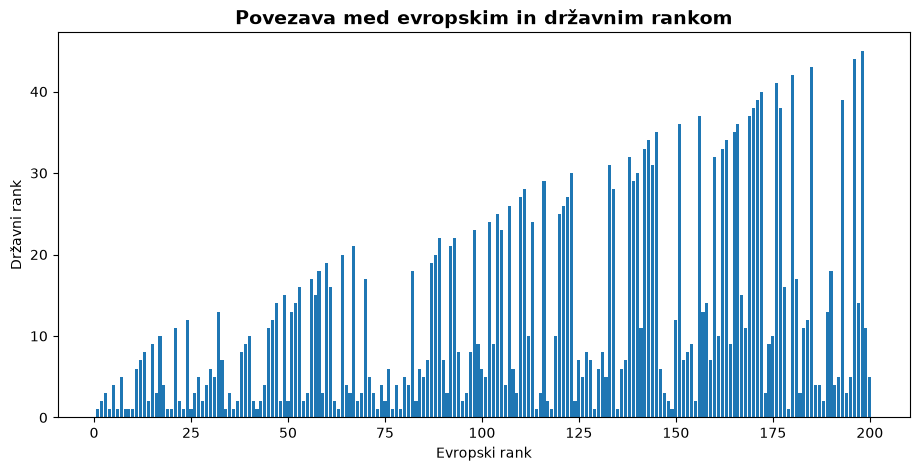

In [237]:

plt.figure(figsize=(11, 5))
plt.bar(podatki_univerz['Evropski rank'], podatki_univerz['Državni rank'])
plt.xlabel('Evropski rank')  
plt.ylabel('Državni rank')
plt.title('Povezava med evropskim in državnim rankom', fontsize=14, fontweight='bold')
plt.show()

Graf je okvirno pokazal linearen trend naraščujočega državnega ranga univerz z naraščujočim evropskim rangom, vendar pa so jasno videna tudi odstopanja, pri katerih gre verjetno za države z manj univerzami. 

Poglejmo si za konec še razpredelnico 10 evropskih držav, katerih je najboljša univerza (državni rank = 1) v evropski lestvici top 200 uvrščena med slabšimi. 

In [238]:
prve_v_drzavi = podatki_univerz[podatki_univerz['Državni rank'] == 1]
tabela = prve_v_drzavi[['Univerza', 'Država', 'Evropski rank']].sort_values('Evropski rank', ascending=False).head(10)
tabela = tabela.reset_index(drop=True)
tabela.index= range(1, len(tabela) + 1)
tabela

,Univerza,Država,Evropski rank
1,Tartu Ülikool,Estonia,179
2,Aristotle University of Thessaloniki,Greece,149
3,Univerza v Ljubljani,Slovenia,135
4,Eötvös Loránd Tudományegyetem,Hungary,129
5,Univerzitet u Beogradu,Serbia,118
6,Uniwersytet Warszawski,Poland,114
7,"Trinity College Dublin, University of Dublin",Ireland,79
8,Universidade de Lisboa,Portugal,77
9,National Research University Higher School of ...,Russia,73
10,Univerzita Karlova,Czech Republic,63
